In [ ]:
import tensorflow as tf
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from tensorflow.keras import layers, models
from qkeras import QConv2D, QDense, quantizers, QActivation


2026-06-08 14:57:56.149903: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-08 14:57:56.157995: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-08 14:57:56.261323: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-08 14:57:56.262039: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-08 14:57:56.817042: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:3

In [3]:
data = sio.loadmat('../data/sat-6-full.mat')
X_train = data['train_x']
y_train = data['train_y']
X_test = data['test_x']
y_test = data['test_y']

X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

X_train = np.transpose(X_train, (3, 0, 1, 2))
X_test  = np.transpose(X_test,  (3, 0, 1, 2))

y_train = np.transpose(y_train, (1, 0))
y_test  = np.transpose(y_test,  (1, 0))

LR = 3e-4
BATCH_SIZE = 512
EPOCHS = 30

optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
loss = "categorical_crossentropy"
metrics = ["accuracy"]

In [4]:
def build_float_model():

    model = models.Sequential()

    model.add(layers.Input(shape=(28, 28, 4)))

    # Conv1: 3x3 stride 2
    model.add(layers.Conv2D(32, (3,3), strides=2, activation="relu", padding="same"))

    # Conv2: 1x1 stride 1
    model.add(layers.Conv2D(64, (1,1), strides=1, activation="relu"))

    model.add(layers.Flatten())

    model.add(layers.Dense(128, activation="relu"))

    model.add(layers.Dense(6, activation="softmax"))

    return model

def compile_and_train(model, X_train, y_train, X_test, y_test):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss=loss,
        metrics=metrics
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        shuffle=True
    )

    return history

In [5]:
float_model = build_float_model()
history_float = compile_and_train(float_model, X_train, y_train, X_test, y_test)

Epoch 1/30
633/633 [==============================] - 11s 17ms/step - loss: 0.1821 - accuracy: 0.9366 - val_loss: 0.1049 - val_accuracy: 0.9593
Epoch 2/30
633/633 [==============================] - 11s 17ms/step - loss: 0.0788 - accuracy: 0.9721 - val_loss: 0.0662 - val_accuracy: 0.9772
Epoch 3/30
633/633 [==============================] - 10s 16ms/step - loss: 0.0665 - accuracy: 0.9765 - val_loss: 0.0563 - val_accuracy: 0.9804
Epoch 4/30
633/633 [==============================] - 10s 16ms/step - loss: 0.0576 - accuracy: 0.9798 - val_loss: 0.0511 - val_accuracy: 0.9821
Epoch 5/30
633/633 [==============================] - 10s 15ms/step - loss: 0.0514 - accuracy: 0.9822 - val_loss: 0.0452 - val_accuracy: 0.9849
Epoch 6/30
633/633 [==============================] - 10s 15ms/step - loss: 0.0485 - accuracy: 0.9833 - val_loss: 0.0432 - val_accuracy: 0.9858
Epoch 7/30
633/633 [==============================] - 10s 15ms/step - loss: 0.0430 - accuracy: 0.9852 - val_loss: 0.0399 - val_accuracy:

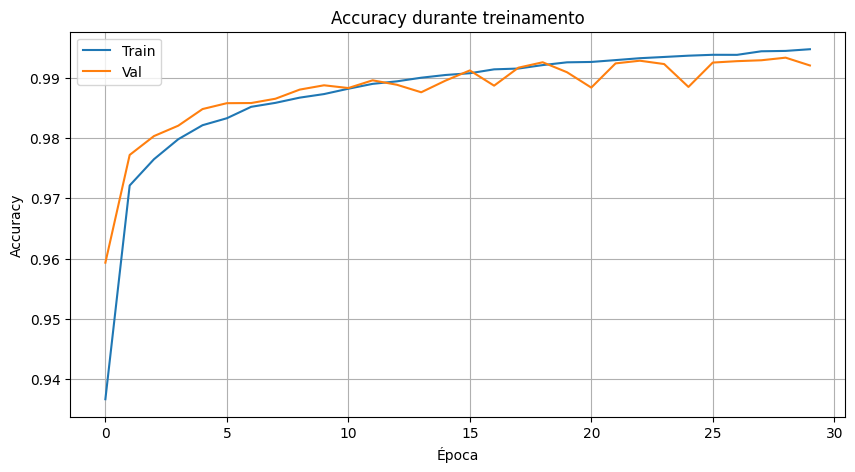

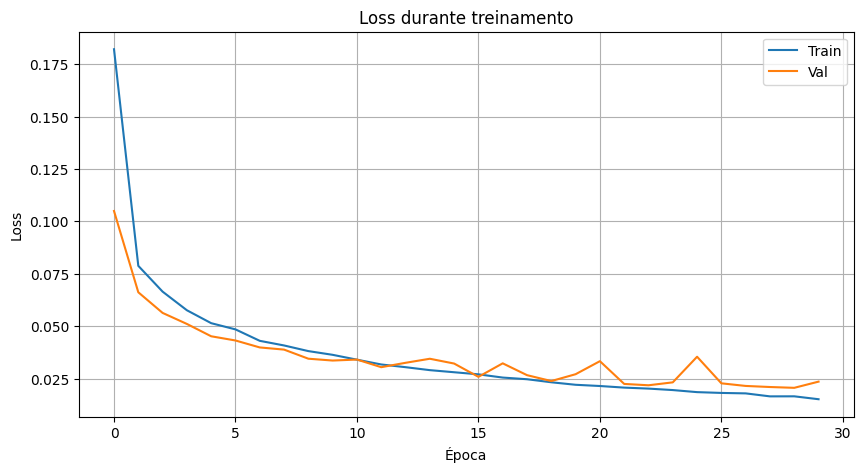

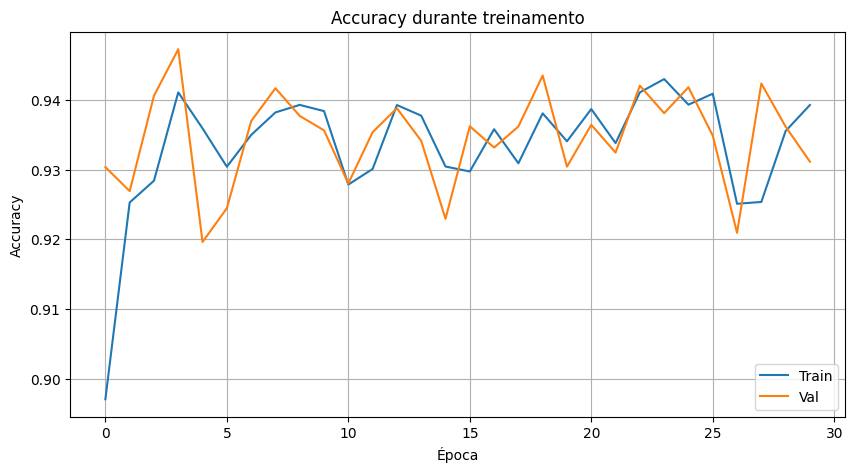

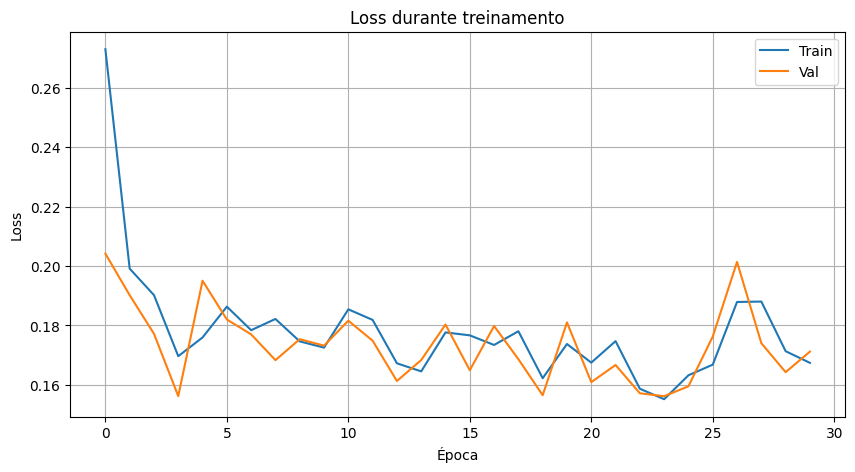

In [ ]:
def plot_history(history):
    # Plotar acurácia
    plt.figure(figsize=(10,5))

    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')

    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.title('Accuracy durante treinamento')
    plt.legend()
    plt.grid(True)

    plt.show()

    # Plotar loss
    plt.figure(figsize=(10,5))

    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')

    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.title('Loss durante treinamento')
    plt.legend()
    plt.grid(True)

    plt.show()

plot_history(history_float)

In [9]:
float_model.evaluate(X_test, y_test, verbose=0)

[0.023542512208223343, 0.9920987486839294]

Classe real: 5
Classe prevista: 5


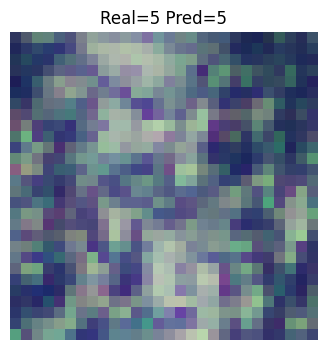

In [23]:
idx = 2

img = X_test[idx]
label = y_test[idx]

pred = float_model.predict(
    np.expand_dims(img, axis=0),
    verbose=0
)

pred_class = np.argmax(pred)
true_class = np.argmax(label)

print("Classe real:", true_class)
print("Classe prevista:", pred_class)

plt.figure(figsize=(4,4))

plt.imshow(img[:, :, :3])

plt.title(
    f"Real={true_class} Pred={pred_class}"
)

plt.axis('off')
plt.show()

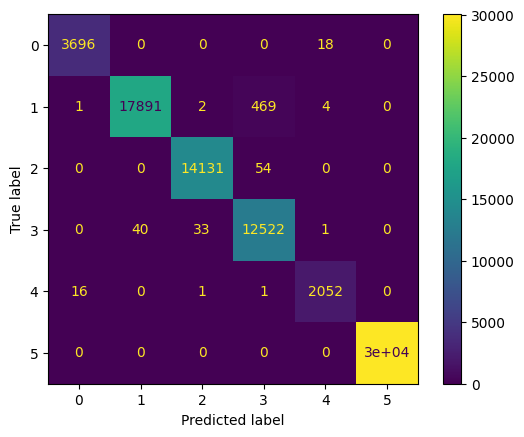

In [ ]:
y_pred = float_model.predict(X_test, verbose=0)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()

In [19]:
preds = float_model.predict(X_test, verbose=0)

preds = np.argmax(preds, axis=1)
truth = np.argmax(y_test, axis=1)

errors = np.where(preds != truth)[0]

print("Número de erros:", len(errors))

Número de erros: 459


In [ ]:
float_model.save("cnn_float.h5")

/home/fauri/Documentos/hls4ml/.venv_hls4ml_t/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
